<a href="https://colab.research.google.com/github/Sampavi01/Hotel_Revenue_Forecasting/blob/forecasting/lstm_manual%20trial/LSTM_Ridge_GridSearch_optimized.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [45]:
# ================== IMPORTS ==================
import os
import random
import itertools
from datetime import timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense

from sklearn.linear_model import Ridge
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

# ================== CONFIG / CONSTANTS ==================
# Suppress TF logs for cleaner output
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
tf.get_logger().setLevel('ERROR')

# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# Path to Excel file
INPUT_FILE_NAME = 'Model_Training_Datasets.xlsx'

# Train/test split settings
TEST_SET_DAYS = 60   # last 60 days reserved for test
VAL_DAYS = 90        # validation fold length
N_SPLITS = 2         # number of CV folds
N_TIMESTEPS = 7      # LSTM sequence window
MAPE_EPSILON = 1e-6  # avoid divide-by-zero in MAPE

# Target columns (meal periods)
TARGET_RAW_COLS = ['Revenue_By_BreakFast', 'Revenue_By_Dinner', 'Revenue_By_Lunch']

# Feature engineering settings
LAG_DAYS = [1, 7, 14]
ROLL_WINDOWS = [7]

# LSTM training settings
LSTM_EPOCHS = 50
LSTM_BATCH_SIZE = 32

# Search spaces (kept from your code)
SEARCH_SPACE_LSTM_LR = [1e-4, 5e-4, 1e-3, 5e-3, 1e-2]
SEARCH_SPACE_LSTM_UNITS = [32, 64, 128]
SEARCH_SPACE_RIDGE_ALPHA = [0.1, 1.0, 10.0, 100.0]

In [46]:
# ================== UTILITY FUNCTIONS ==================
def add_lag_and_rolling(df, target_cols, lag_days, roll_windows):
    """
    Add lag and rolling features for each target column.
    Shift ensures only past values are used (no leakage).
    """
    df = df.copy()
    for col in target_cols:
        for lag in lag_days:
            df[f'{col}_lag{lag}'] = df[col].shift(lag)
        if pd.api.types.is_numeric_dtype(df[col]):
            for w in roll_windows:
                df[f'{col}_rollmean{w}'] = df[col].rolling(window=w, min_periods=1).mean().shift(1)
                df[f'{col}_rollstd{w}'] = df[col].rolling(window=w, min_periods=1).std().shift(1).fillna(0)
    return df.fillna(0)


def create_sequences(data, target, n_timesteps):
    """
    Convert tabular data into sequences for LSTM.
    Each sample uses n_timesteps of history to predict the next target.
    """
    X, y = [], []
    for i in range(len(data) - n_timesteps):
        X.append(data[i:(i + n_timesteps), :])
        y.append(target[i + n_timesteps])
    return np.array(X), np.array(y)


def smape(y_true, y_pred, eps=1e-6):
    """
    Symmetric MAPE (%) robust to near-zeros.
    """
    numer = np.abs(y_pred - y_true)
    denom = (np.abs(y_true) + np.abs(y_pred)).clip(min=eps)
    return np.mean(2.0 * numer / denom) * 100.0


def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))


def build_lstm_hybrid_model(input_shape_lstm, lr, units):
    """
    Build LSTM + Dense hybrid model with Adam optimizer.
    Upgraded to:
      - 2 LSTM layers (stacked)
      - 2 Dense hidden layers (funnel-shaped)
    Keeps the same signature (input_shape_lstm, lr, units) as your original.
    """
    lstm_input = Input(shape=input_shape_lstm, name='lstm_input')

    # LSTM stack (two layers)
    lstm_out1 = LSTM(units, return_sequences=True, name='lstm_1')(lstm_input)
    lstm_out2 = LSTM(units, return_sequences=False, name='lstm_2')(lstm_out1)

    # Dense hidden layers (funnel: units//2 → units//4; min 8 to avoid zero)
    dense_hidden1 = Dense(max(units // 2, 8), activation='relu', name='dense_hidden_1')(lstm_out2)
    dense_hidden2 = Dense(max(units // 4, 8), activation='relu', name='dense_hidden_2')(dense_hidden1)

    # Output
    output = Dense(1, activation='linear', name='output')(dense_hidden2)

    model = Model(inputs=lstm_input, outputs=output)
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    model.compile(optimizer=optimizer, loss='mse')
    return model


def dynamic_weights(y_true, y_pred_a, y_pred_b):
    """
    Compute ensemble weights based on RMSE of each model.
    Lower RMSE → higher weight.
    """
    rmse_a = np.sqrt(mean_squared_error(y_true, y_pred_a))
    rmse_b = np.sqrt(mean_squared_error(y_true, y_pred_b))
    total = rmse_a + rmse_b if (rmse_a + rmse_b) > 0 else 1.0
    w_a = 1 - (rmse_a / total)
    w_b = 1 - w_a
    return w_a, w_b


# ================== PLOTTING ==================
def plot_test_results(test_df, center_name, meal_period):
    """
    Plot actual vs predicted revenue for test set.
    """
    plt.figure(figsize=(12, 6))
    plt.plot(test_df['Date'], test_df['Actual_Revenue'], label='Actual Revenue', marker='o')
    plt.plot(test_df['Date'], test_df['Predicted_Revenue'], label='Predicted Revenue', marker='x')
    plt.title(f'Actual vs Predicted Revenue (Test) - {center_name} - {meal_period}')
    plt.xlabel('Date'); plt.ylabel('Revenue'); plt.legend()
    plt.grid(True, alpha=0.5); plt.xticks(rotation=45); plt.tight_layout(); plt.show()


def plot_residuals_over_time(residuals_df, center_name, meal_period):
    """
    Plot residuals (Actual - Predicted) over time for test set.
    """
    residuals_df = residuals_df.copy()
    residuals_df['Residual'] = residuals_df['Actual_Revenue'] - residuals_df['Predicted_Revenue']
    plt.figure(figsize=(12, 5))
    plt.plot(residuals_df['Date'], residuals_df['Residual'], marker='.', linestyle='None', alpha=0.6)
    plt.axhline(0, color='red', linestyle='--')
    plt.title(f'Test Residuals Over Time - {center_name} - {meal_period}')
    plt.xlabel('Date'); plt.ylabel('Residual'); plt.grid(True, alpha=0.5)
    plt.xticks(rotation=45); plt.tight_layout(); plt.show()

In [47]:
# ================== CV SCORING (UNCHANGED) ==================
def score_ensemble_lstm_and_weights(params, X_train_full, Y_train_full, tscv,
                                    raw_target_col, numeric_features, categorical_features):
    """
    Perform CV scoring for given hyperparameters.
    Returns:
      - avg_rmse across folds
      - avg_w_lstm across folds
      - avg_w_ridge across folds
    Ensemble weights are computed per fold on the validation set, then averaged across folds.
    """
    lr, units, alpha = params
    fold_rmses, fold_w_lstm, fold_w_ridge = [], [], []

    for train_idx, val_idx in tscv.split(X_train_full):
        # Split train/val
        X_train_cv_raw, X_val_raw = X_train_full.iloc[train_idx], X_train_full.iloc[val_idx]
        Y_train_cv = Y_train_full.iloc[train_idx][raw_target_col]
        Y_val = Y_train_full.iloc[val_idx][raw_target_col]

        # Scale numeric features (fit on train only)
        scaler = StandardScaler()
        X_train_num_scaled = scaler.fit_transform(X_train_cv_raw[numeric_features])
        X_val_num_scaled = scaler.transform(X_val_raw[numeric_features])

        # Combine numeric + categorical
        X_train_cv_scaled = pd.concat(
            [pd.DataFrame(X_train_num_scaled, columns=numeric_features, index=X_train_cv_raw.index),
             X_train_cv_raw[categorical_features]], axis=1)
        X_val_scaled = pd.concat(
            [pd.DataFrame(X_val_num_scaled, columns=numeric_features, index=X_val_raw.index),
             X_val_raw[categorical_features]], axis=1)

        # Sequence creation
        X_seq_train, Y_seq_train = create_sequences(X_train_cv_scaled.values, Y_train_cv.values, N_TIMESTEPS)
        X_seq_val, Y_seq_val = create_sequences(X_val_scaled.values, Y_val.values, N_TIMESTEPS)
        if len(X_seq_train) == 0 or len(X_seq_val) == 0:
            continue

        # Ridge data aligned with sequences
        X_ridge_train = X_train_cv_scaled.iloc[N_TIMESTEPS:]
        X_ridge_val = X_val_scaled.iloc[N_TIMESTEPS:]
        Y_ridge_train = Y_train_cv.iloc[N_TIMESTEPS:]

        # Train LSTM (now 2 LSTM + 2 Dense hidden layers)
        tf.keras.backend.clear_session()
        lstm_model = build_lstm_hybrid_model((N_TIMESTEPS, X_seq_train.shape[2]), lr, units)
        es_callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
        lstm_model.fit(X_seq_train, Y_seq_train,
                       validation_data=(X_seq_val, Y_seq_val),
                       epochs=LSTM_EPOCHS, batch_size=LSTM_BATCH_SIZE,
                       callbacks=[es_callback], verbose=0)
        y_pred_lstm = lstm_model.predict(X_seq_val, verbose=0).flatten()

        # Train Ridge
        ridge_model = Ridge(alpha=alpha).fit(X_ridge_train, Y_ridge_train)
        y_pred_ridge = ridge_model.predict(X_ridge_val).flatten()

        # Align lengths
        min_len = min(len(Y_seq_val), len(y_pred_lstm), len(y_pred_ridge))
        if min_len == 0:
            continue

        # Truncate to aligned length
        Y_seq_val_trunc = Y_seq_val[:min_len]
        y_pred_lstm_trunc = y_pred_lstm[:min_len]
        y_pred_ridge_trunc = y_pred_ridge[:min_len]

        # Compute ensemble weights on validation only (no leakage)
        w_lstm, w_ridge = dynamic_weights(Y_seq_val_trunc, y_pred_lstm_trunc, y_pred_ridge_trunc)
        y_pred_val_ens = (w_lstm * y_pred_lstm_trunc) + (w_ridge * y_pred_ridge_trunc)

        # Fold RMSE
        rmse = np.sqrt(mean_squared_error(Y_seq_val_trunc, y_pred_val_ens))
        fold_rmses.append(rmse)
        fold_w_lstm.append(w_lstm)
        fold_w_ridge.append(w_ridge)

    # Return averages across folds
    return (np.mean(fold_rmses) if fold_rmses else float('inf'),
            float(np.mean(fold_w_lstm)) if fold_w_lstm else 0.5,
            float(np.mean(fold_w_ridge)) if fold_w_ridge else 0.5)

In [48]:
# ================== RANDOM SEARCH (NEW, MINIMAL INTRUSION) ==================
def random_search_tune(X_train_full, Y_train_full, tscv, raw_target_col,
                       numeric_features, categorical_features,
                       lr_list, units_list, alpha_list, n_trials=12):
    """
    Randomly sample 'n_trials' combinations from the discrete search space lists.
    Returns best (avg_cv_rmse, avg_w_lstm, avg_w_ridge, best_params).
    """
    grid = list(itertools.product(lr_list, units_list, alpha_list))
    combos = random.sample(grid, min(n_trials, len(grid)))

    best_rmse = float('inf')
    best_params = None
    best_w = (0.5, 0.5)

    for params in combos:
        avg_rmse, w_lstm, w_ridge = score_ensemble_lstm_and_weights(
            params=params,
            X_train_full=X_train_full,
            Y_train_full=Y_train_full,
            tscv=tscv,
            raw_target_col=raw_target_col,
            numeric_features=numeric_features,
            categorical_features=categorical_features
        )
        if avg_rmse < best_rmse:
            best_rmse = avg_rmse
            best_params = params
            best_w = (w_lstm, w_ridge)

    return best_rmse, best_w[0], best_w[1], best_params


def get_small_ranges_for_period(meal_period):
    """
    Optional: tighten ranges based on your observed winners.
    Falls back to global lists if not matched.
    """
    if meal_period == 'BreakFast':
        return [1e-3, 5e-3, 1e-2], [64], [10.0]
    if meal_period == 'Dinner':
        return [1e-4, 5e-4, 1e-3], [128, 64], [1.0, 10.0]
    if meal_period == 'Lunch':
        return [5e-4, 1e-3, 2e-3], [64, 128], [10.0, 100.0]
    return SEARCH_SPACE_LSTM_LR, SEARCH_SPACE_LSTM_UNITS, SEARCH_SPACE_RIDGE_ALPHA


# ================== MAIN TRAINING FUNCTION ==================
def train_and_plot_for_center(df_center, center_name):
    """
    Train hybrid LSTM + Ridge model for one revenue center.
    Uses random search (small, fast) with CV, retrains on full training set,
    evaluates on test set, and plots results.
    """
    # Feature engineering
    df_center = add_lag_and_rolling(df_center, TARGET_RAW_COLS, LAG_DAYS, ROLL_WINDOWS)
    df_center = df_center.sort_values('Date').reset_index(drop=True)

    # Train/test split by date
    max_date = df_center['Date'].max()
    test_start_date = max_date - timedelta(days=TEST_SET_DAYS)
    df_train_full = df_center[df_center['Date'] < test_start_date].copy().dropna()
    df_test_full = df_center[df_center['Date'] >= test_start_date].copy()

    if df_train_full.empty or df_test_full.empty:
        print(f"Skipping center {center_name}: Training or Test set is empty.")
        return

    # TimeSeriesSplit with gap to avoid leakage
    tscv = TimeSeriesSplit(n_splits=N_SPLITS, test_size=VAL_DAYS, gap=N_TIMESTEPS)

    # Separate features
    feature_cols = [c for c in df_train_full.columns if c not in ['Date'] + TARGET_RAW_COLS]
    numeric_features = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df_train_full[c])]
    categorical_features = [c for c in feature_cols if c not in numeric_features]

    X_train_full = df_train_full[feature_cols]
    Y_train_full = df_train_full[TARGET_RAW_COLS]

    # Train each meal period separately
    for raw_target_col in TARGET_RAW_COLS:
        meal_period = raw_target_col.replace('Revenue_By_', '')

        # Use small ranges by period (or fallback to global)
        lr_list, units_list, alpha_list = get_small_ranges_for_period(meal_period)

        print(f"\n🎲 Random Search for {center_name} - {meal_period}: "
              f"{min(12, len(list(itertools.product(lr_list, units_list, alpha_list))))} sampled combos")

        # Random search loop (reusing your CV scorer)
        best_cv_rmse, w_lstm_cv, w_ridge_cv, best_params = random_search_tune(
            X_train_full=X_train_full,
            Y_train_full=Y_train_full,
            tscv=tscv,
            raw_target_col=raw_target_col,
            numeric_features=numeric_features,
            categorical_features=categorical_features,
            lr_list=lr_list,
            units_list=units_list,
            alpha_list=alpha_list,
            n_trials=12
        )

        best_lr, best_units, best_alpha = best_params

        print(f"✅ Best Params for {center_name} - {meal_period}: "
              f"LR={best_lr:.5f}, Units={best_units}, Alpha={best_alpha:.2f}, Avg CV RMSE={best_cv_rmse:.2f}")
        print(f"✅ Ensemble weights (from CV): LSTM={w_lstm_cv:.3f}, Ridge={w_ridge_cv:.3f}")

        # Final training on full training set
        final_scaler = StandardScaler()
        X_train_full_scaled = pd.DataFrame(
            final_scaler.fit_transform(X_train_full[numeric_features]),
            columns=numeric_features,
            index=X_train_full.index
        )
        X_train_final = pd.concat([X_train_full_scaled, df_train_full[categorical_features]], axis=1)

        Y_train_target = Y_train_full[raw_target_col].values
        X_seq_train_final, Y_seq_train_final = create_sequences(X_train_final.values, Y_train_target, N_TIMESTEPS)
        if len(X_seq_train_final) == 0:
            print(f"Not enough data for LSTM sequences in {center_name} - {meal_period}. Skipping.")
            continue

        X_ridge_train_final = X_train_final.iloc[N_TIMESTEPS:]
        Y_ridge_train_final = Y_train_full[raw_target_col].iloc[N_TIMESTEPS:]

        tf.keras.backend.clear_session()
        final_lstm_model = build_lstm_hybrid_model((N_TIMESTEPS, X_seq_train_final.shape[2]), best_lr, best_units)
        es_callback = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)
        final_lstm_model.fit(X_seq_train_final, Y_seq_train_final,
                             epochs=LSTM_EPOCHS, batch_size=LSTM_BATCH_SIZE,
                             callbacks=[es_callback], verbose=0)

        final_ridge_model = Ridge(alpha=best_alpha).fit(X_ridge_train_final, Y_ridge_train_final)

        # Prepare test set
        X_test_scaled = pd.DataFrame(
            final_scaler.transform(df_test_full[numeric_features]),
            columns=numeric_features,
            index=df_test_full.index
        )
        X_test_final = pd.concat([X_test_scaled, df_test_full[categorical_features]], axis=1).fillna(0)
        Y_test_raw = df_test_full[raw_target_col].values

        # Build continuous sequence for test
        X_full_for_test = pd.concat([X_train_final.tail(N_TIMESTEPS), X_test_final], ignore_index=True).values
        X_seq_test, _ = create_sequences(X_full_for_test, np.zeros_like(X_full_for_test[:, 0]), N_TIMESTEPS)

        y_test_lstm = final_lstm_model.predict(X_seq_test, verbose=0).flatten()
        y_test_ridge = final_ridge_model.predict(X_test_final).flatten()

        min_len_test = min(len(Y_test_raw), len(y_test_lstm), len(y_test_ridge))
        if min_len_test <= 0:
            print(f"Skipping final prediction for {center_name} - {meal_period}: Test data too short.")
            continue

        Y_test_raw_trunc = Y_test_raw[:min_len_test]
        y_test_lstm_trunc = y_test_lstm[:min_len_test]
        y_test_ridge_trunc = y_test_ridge[:min_len_test]

        # Ensemble using CV-derived weights (no test leakage)
        y_test_ens = (w_lstm_cv * y_test_lstm_trunc) + (w_ridge_cv * y_test_ridge_trunc)

        # Metrics: RMSE, MAPE (your original), plus MAE and sMAPE (robust to near-zero)
        test_rmse = np.sqrt(mean_squared_error(Y_test_raw_trunc, y_test_ens))
        test_mape = np.mean(np.abs(Y_test_raw_trunc - y_test_ens) /
                            np.maximum(Y_test_raw_trunc, MAPE_EPSILON)) * 100
        test_mae = mae(Y_test_raw_trunc, y_test_ens)
        test_smape = smape(Y_test_raw_trunc, y_test_ens)

        print(f"\n--- FINAL TEST RESULTS ({center_name} - {meal_period}) ---")
        print(f"TEST RMSE: {test_rmse:.2f}, TEST MAE: {test_mae:.2f}, TEST sMAPE: {test_smape:.2f}%, TEST MAPE: {test_mape:.2f}%")

        # Plot results
        plot_df = pd.DataFrame({
            'Date': df_test_full['Date'].iloc[:min_len_test],
            'Actual_Revenue': Y_test_raw_trunc,
            'Predicted_Revenue': y_test_ens
        })
        plot_test_results(plot_df, center_name, meal_period)
        plot_residuals_over_time(plot_df, center_name, meal_period)


================= Revenue Centre 1 =================

🎲 Random Search for Revenue Centre 1 - BreakFast: 3 sampled combos
✅ Best Params for Revenue Centre 1 - BreakFast: LR=0.01000, Units=64, Alpha=10.00, Avg CV RMSE=959.81
✅ Ensemble weights (from CV): LSTM=0.464, Ridge=0.536

--- FINAL TEST RESULTS (Revenue Centre 1 - BreakFast) ---
TEST RMSE: 1085.62, TEST MAE: 705.81, TEST sMAPE: 62.45%, TEST MAPE: 510927329.09%


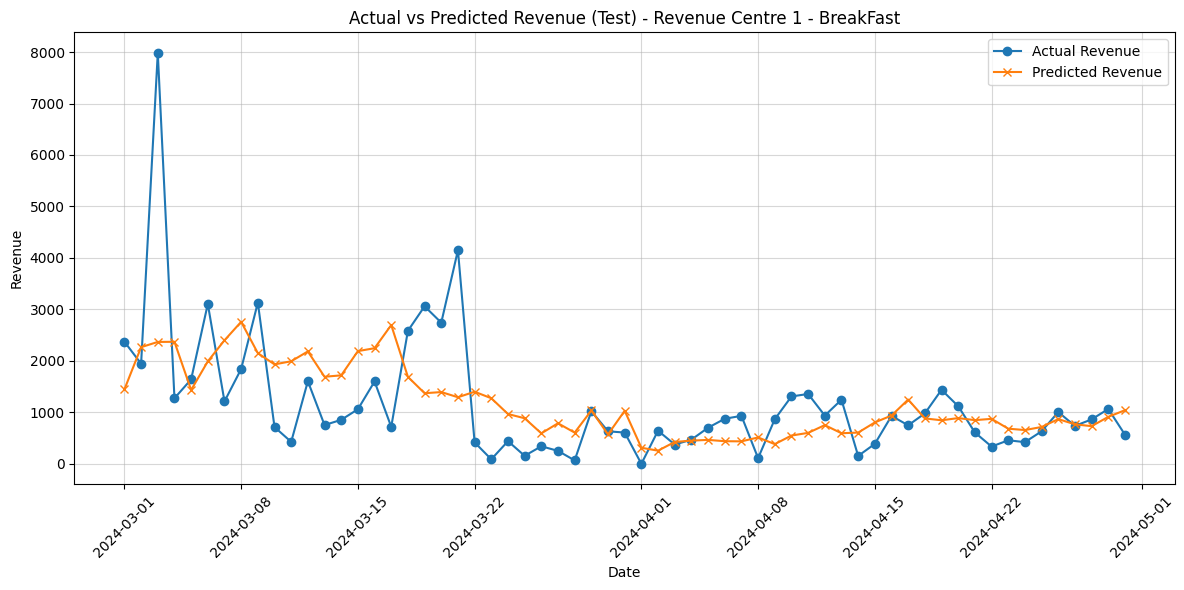

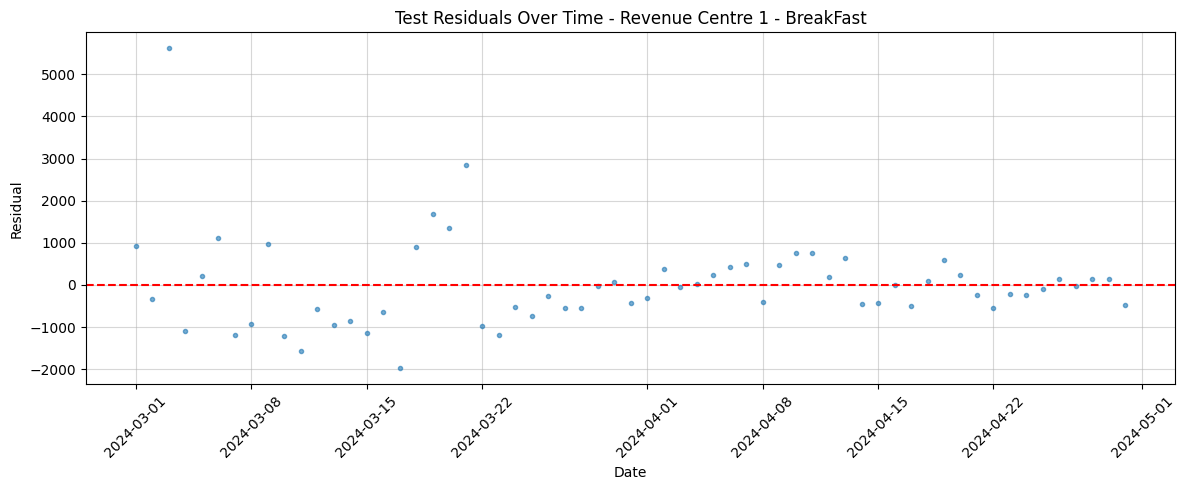


🎲 Random Search for Revenue Centre 1 - Dinner: 12 sampled combos
✅ Best Params for Revenue Centre 1 - Dinner: LR=0.00050, Units=128, Alpha=1.00, Avg CV RMSE=1563.22
✅ Ensemble weights (from CV): LSTM=0.445, Ridge=0.555

--- FINAL TEST RESULTS (Revenue Centre 1 - Dinner) ---
TEST RMSE: 1573.86, TEST MAE: 1169.65, TEST sMAPE: 42.89%, TEST MAPE: 67.81%


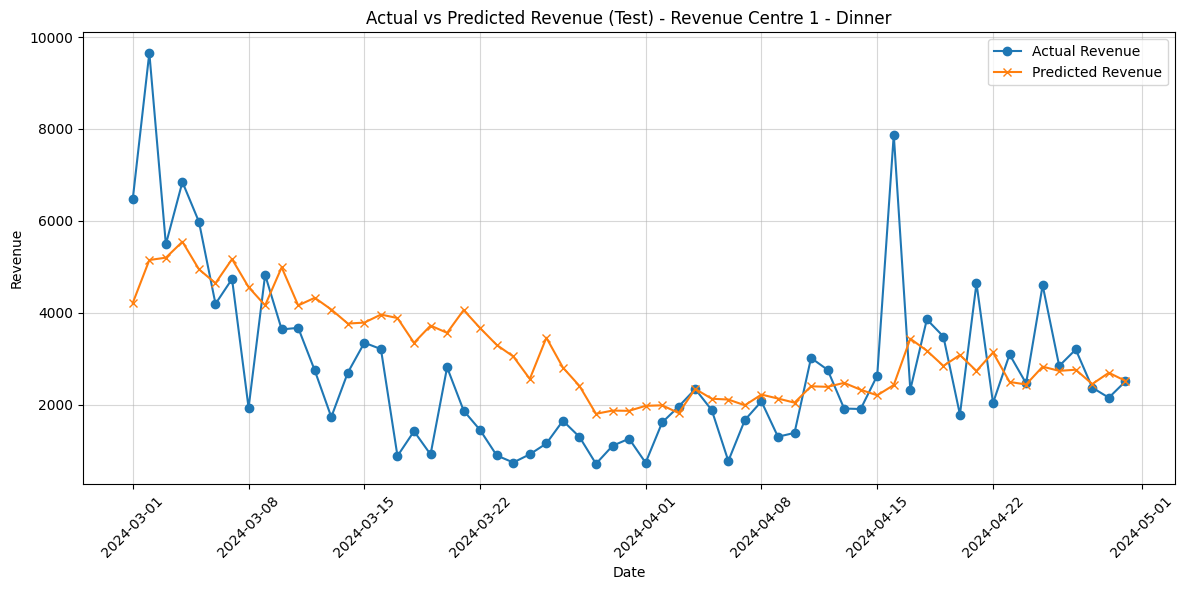

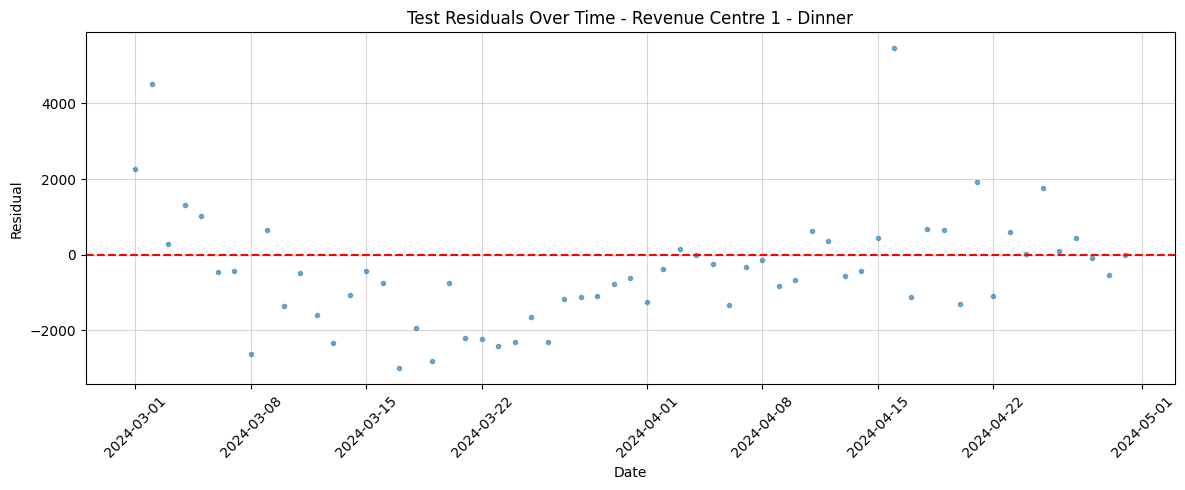


🎲 Random Search for Revenue Centre 1 - Lunch: 12 sampled combos
✅ Best Params for Revenue Centre 1 - Lunch: LR=0.00200, Units=128, Alpha=10.00, Avg CV RMSE=791.00
✅ Ensemble weights (from CV): LSTM=0.488, Ridge=0.512

--- FINAL TEST RESULTS (Revenue Centre 1 - Lunch) ---
TEST RMSE: 664.41, TEST MAE: 528.85, TEST sMAPE: 70.20%, TEST MAPE: 1976157769.50%


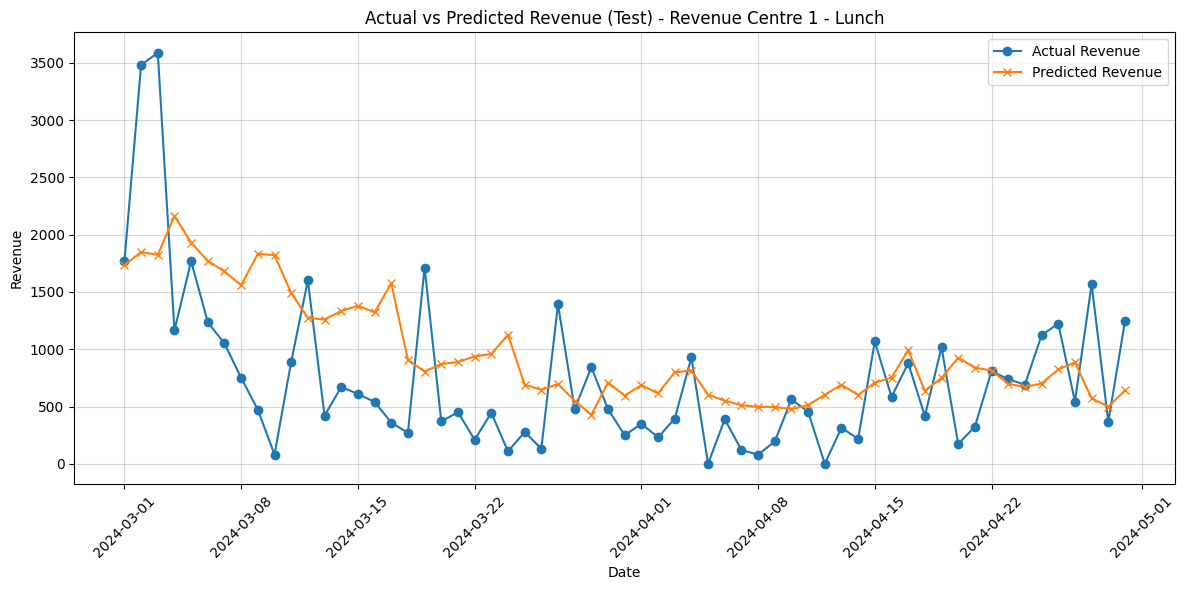

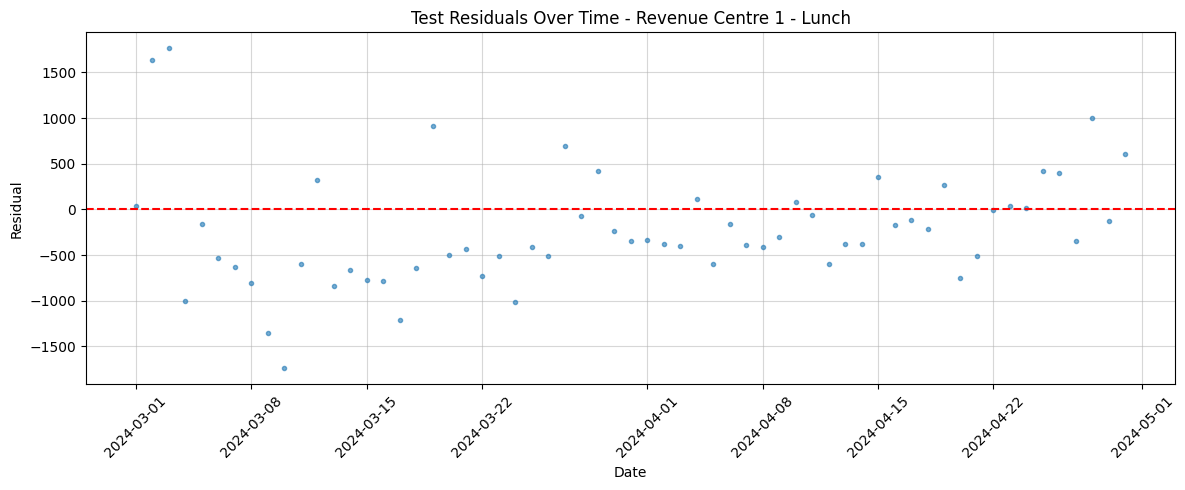


================= Revenue Centre 2 =================

🎲 Random Search for Revenue Centre 2 - BreakFast: 3 sampled combos
✅ Best Params for Revenue Centre 2 - BreakFast: LR=0.00100, Units=64, Alpha=10.00, Avg CV RMSE=349.19
✅ Ensemble weights (from CV): LSTM=0.526, Ridge=0.474

--- FINAL TEST RESULTS (Revenue Centre 2 - BreakFast) ---
TEST RMSE: 464.79, TEST MAE: 277.12, TEST sMAPE: 99.79%, TEST MAPE: 8940398772.91%


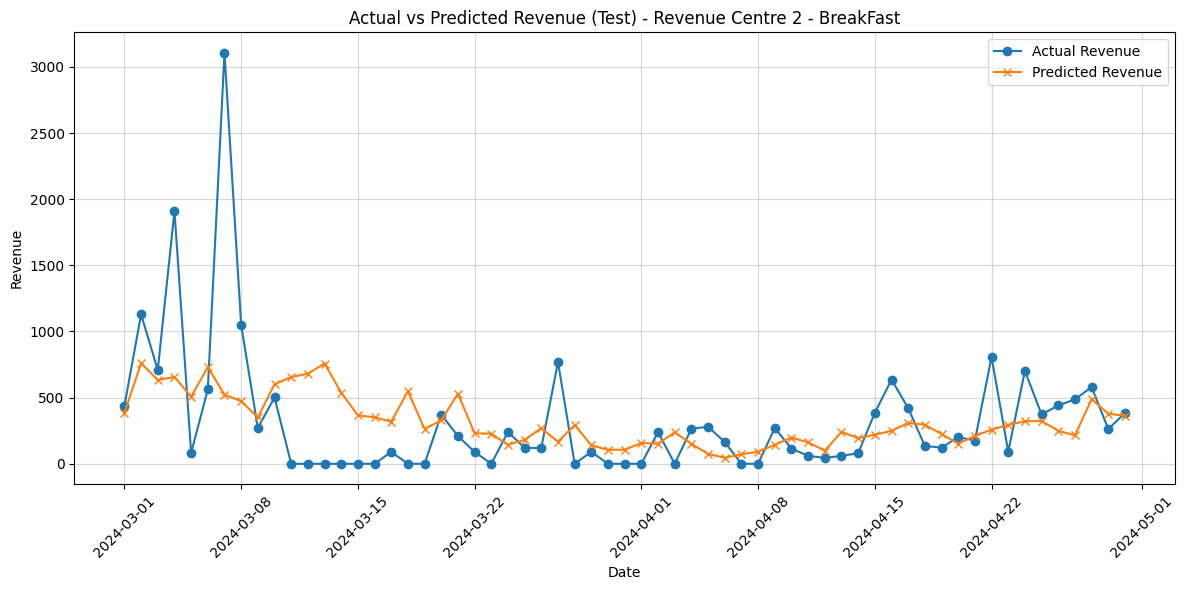

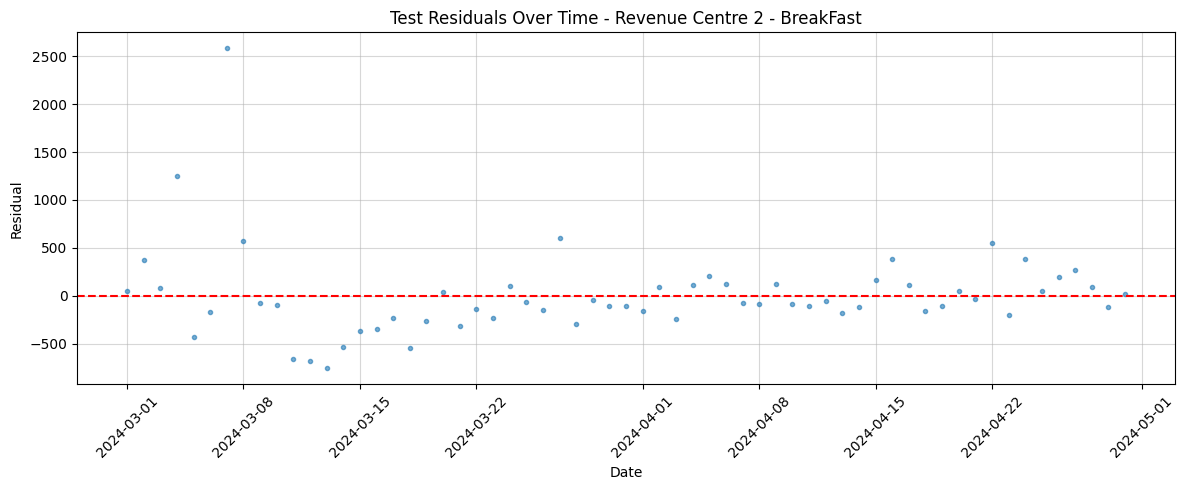


🎲 Random Search for Revenue Centre 2 - Dinner: 12 sampled combos
✅ Best Params for Revenue Centre 2 - Dinner: LR=0.00100, Units=128, Alpha=1.00, Avg CV RMSE=879.19
✅ Ensemble weights (from CV): LSTM=0.512, Ridge=0.488

--- FINAL TEST RESULTS (Revenue Centre 2 - Dinner) ---
TEST RMSE: 743.27, TEST MAE: 503.88, TEST sMAPE: 98.78%, TEST MAPE: 8045579757.71%


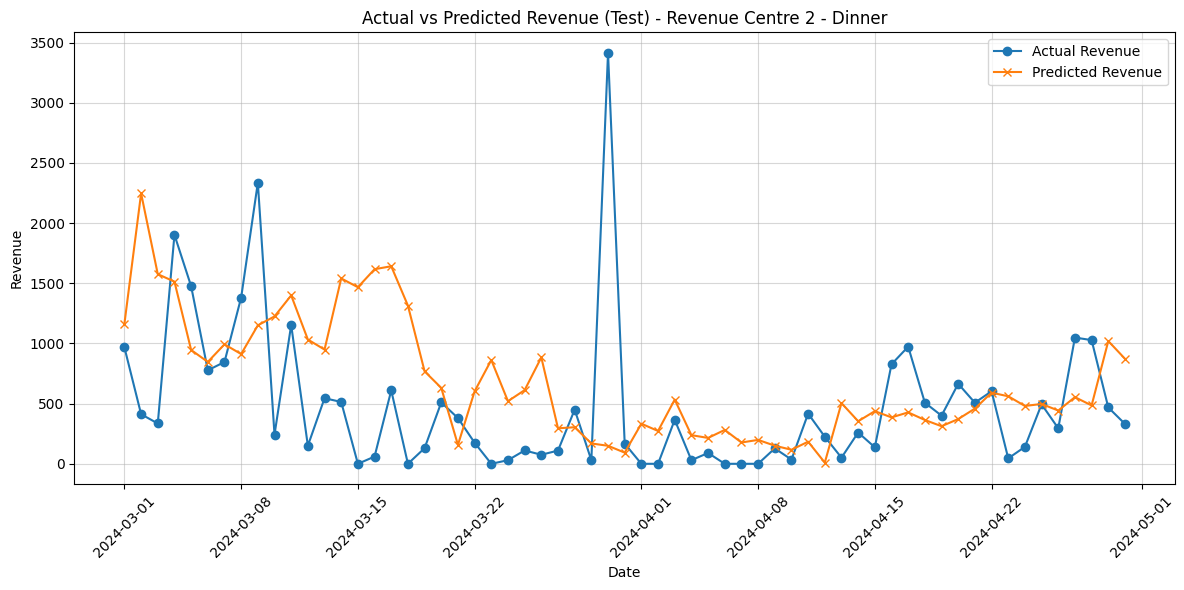

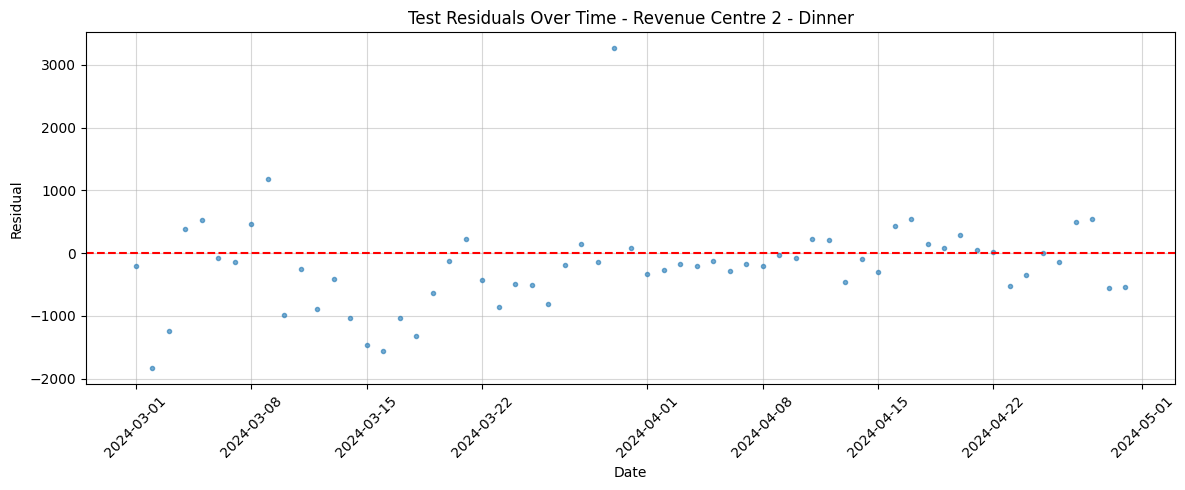


🎲 Random Search for Revenue Centre 2 - Lunch: 12 sampled combos
✅ Best Params for Revenue Centre 2 - Lunch: LR=0.00100, Units=64, Alpha=10.00, Avg CV RMSE=426.47
✅ Ensemble weights (from CV): LSTM=0.505, Ridge=0.495

--- FINAL TEST RESULTS (Revenue Centre 2 - Lunch) ---
TEST RMSE: 891.74, TEST MAE: 417.85, TEST sMAPE: 91.21%, TEST MAPE: 5487619847.05%


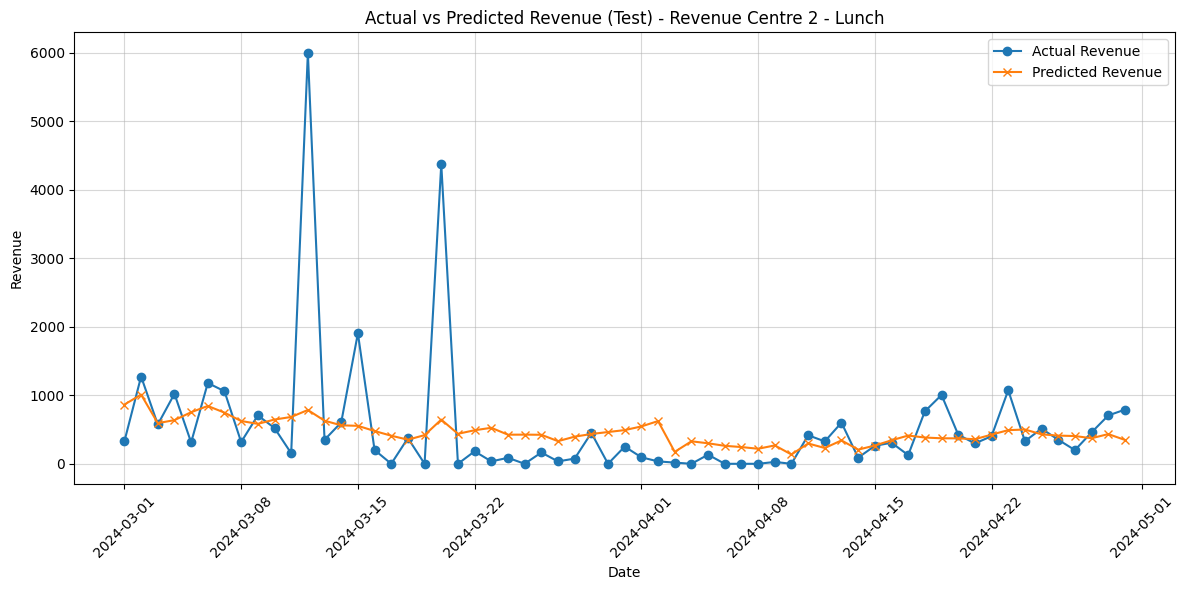

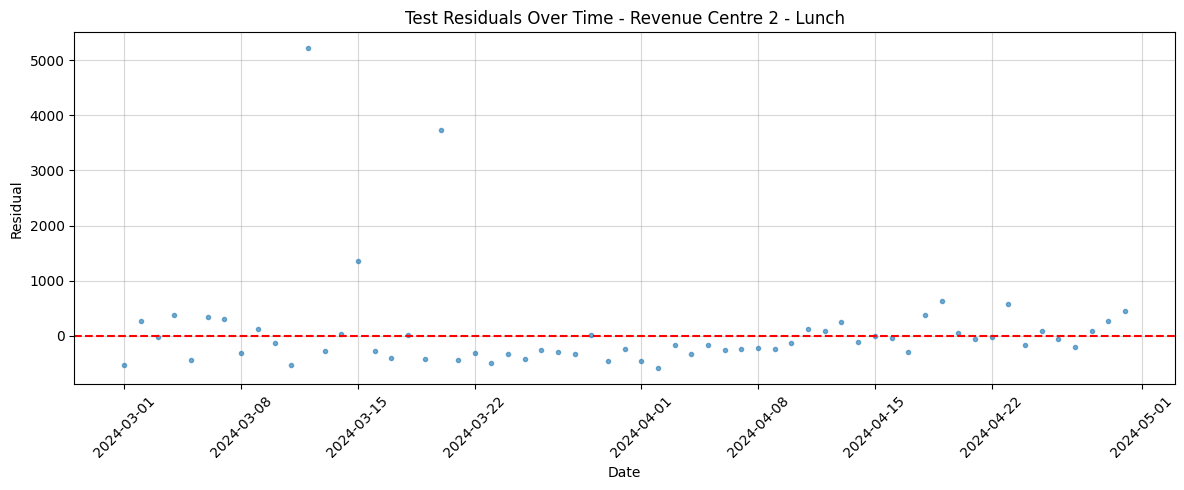

In [49]:
# ================== LOAD CENTERS 1–5 AND RUN ==================
def load_center_from_excel(file_path, center_sheet_name):
    """
    Load one center's sheet from Excel and parse Date column.
    """
    df = pd.read_excel(file_path, sheet_name=center_sheet_name)
    if 'Date' in df.columns:
        df['Date'] = pd.to_datetime(df['Date'])
    else:
        raise ValueError("Expected a 'Date' column in the sheet.")
    return df


if __name__ == '__main__':
    # Iterate through centers 1 to 5
    for center_id in range(0, 2):
        try:
            # Load sheet by numeric name (1, 2, 3, 4, 5)
            df_center = load_center_from_excel(INPUT_FILE_NAME, center_id)
            display_name = f"Revenue Centre {center_id+1}"
            print(f"\n================= {display_name} =================")
            # Train and evaluate for this center
            train_and_plot_for_center(df_center, display_name)
        except Exception as e:
            print(f"⚠️ Skipping {center_id}: {e}")


================= Revenue Centre 3 =================

🎲 Random Search for Revenue Centre 3 - BreakFast: 3 sampled combos
✅ Best Params for Revenue Centre 3 - BreakFast: LR=0.01000, Units=64, Alpha=10.00, Avg CV RMSE=377.81
✅ Ensemble weights (from CV): LSTM=0.513, Ridge=0.487

--- FINAL TEST RESULTS (Revenue Centre 3 - BreakFast) ---
TEST RMSE: 324.13, TEST MAE: 243.67, TEST sMAPE: 101.35%, TEST MAPE: 6046697877.12%


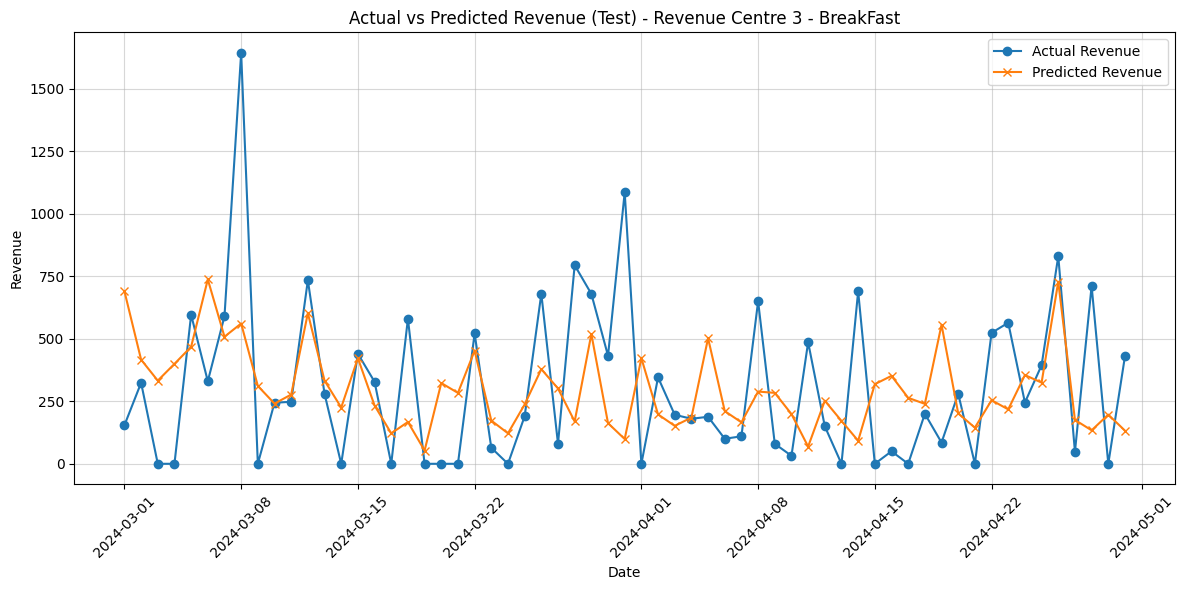

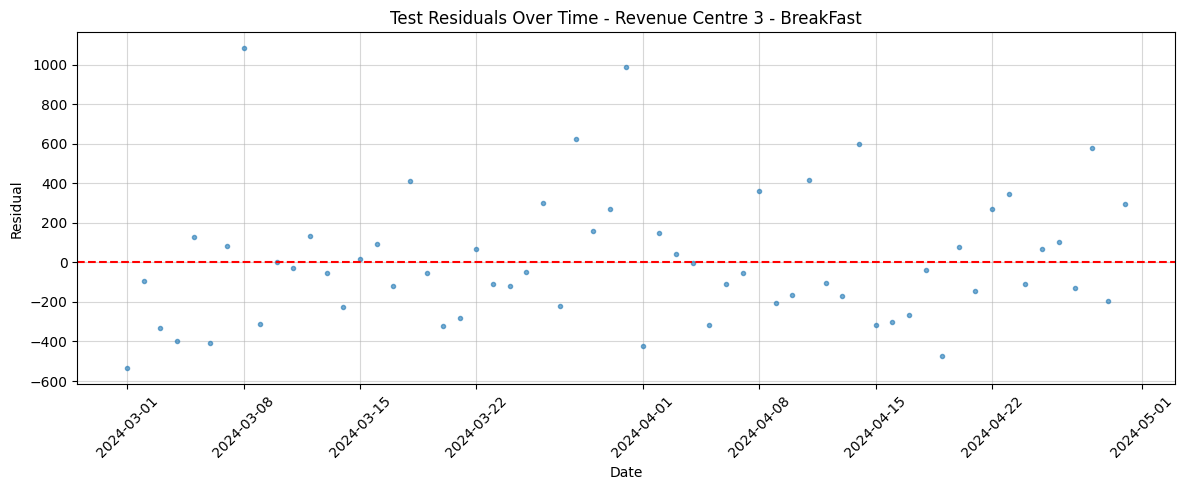


🎲 Random Search for Revenue Centre 3 - Dinner: 12 sampled combos
✅ Best Params for Revenue Centre 3 - Dinner: LR=0.00100, Units=128, Alpha=1.00, Avg CV RMSE=4643.51
✅ Ensemble weights (from CV): LSTM=0.405, Ridge=0.595

--- FINAL TEST RESULTS (Revenue Centre 3 - Dinner) ---
TEST RMSE: 8749.02, TEST MAE: 4645.57, TEST sMAPE: 35.99%, TEST MAPE: 47.34%


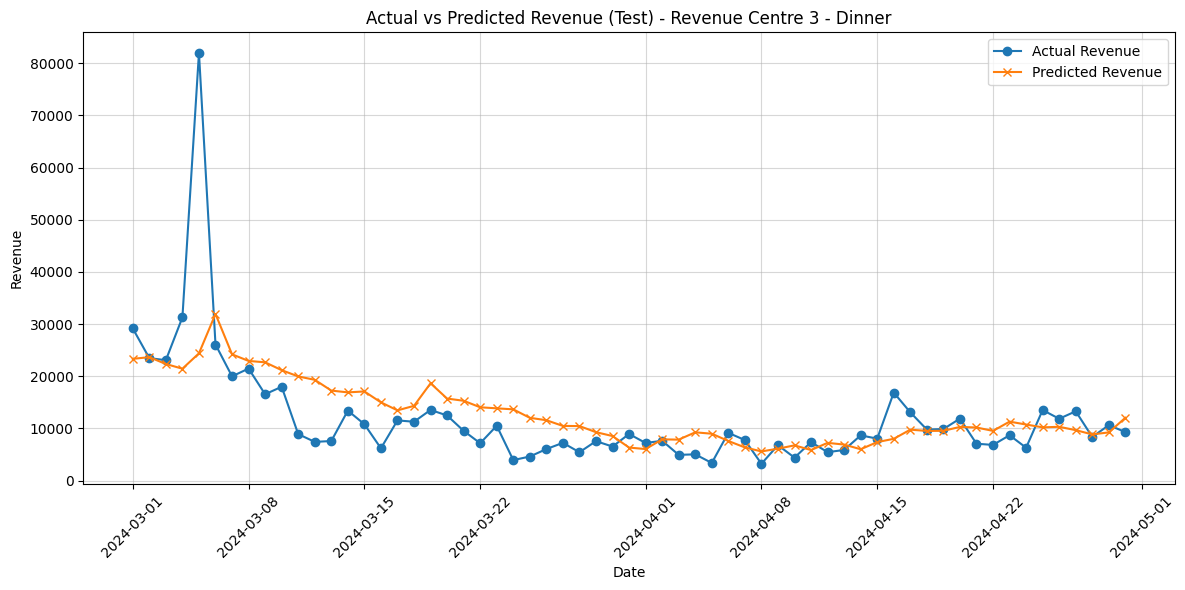

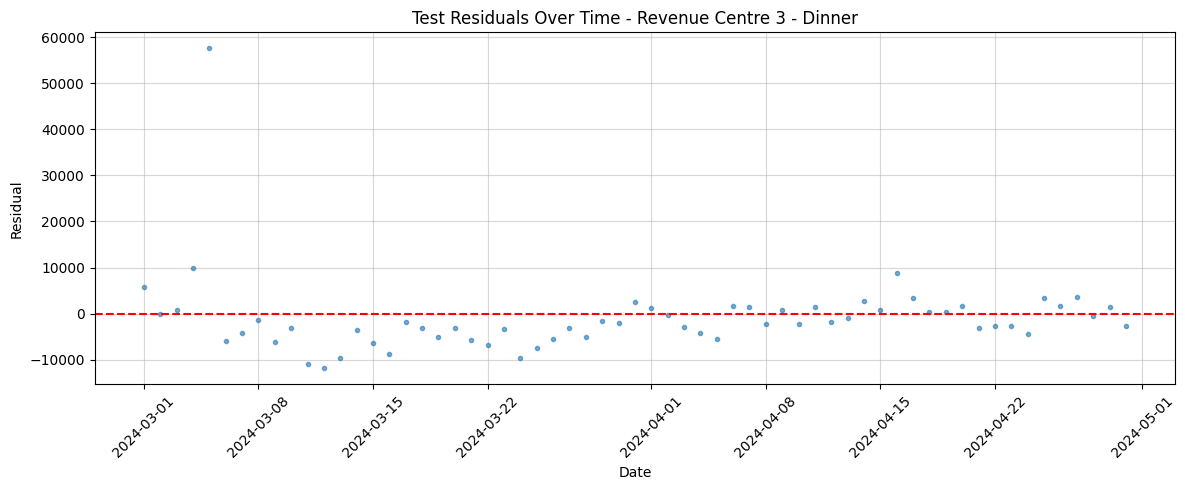


🎲 Random Search for Revenue Centre 3 - Lunch: 12 sampled combos
✅ Best Params for Revenue Centre 3 - Lunch: LR=0.00200, Units=64, Alpha=10.00, Avg CV RMSE=1040.97
✅ Ensemble weights (from CV): LSTM=0.487, Ridge=0.513

--- FINAL TEST RESULTS (Revenue Centre 3 - Lunch) ---
TEST RMSE: 1116.84, TEST MAE: 848.99, TEST sMAPE: 42.30%, TEST MAPE: 53.60%


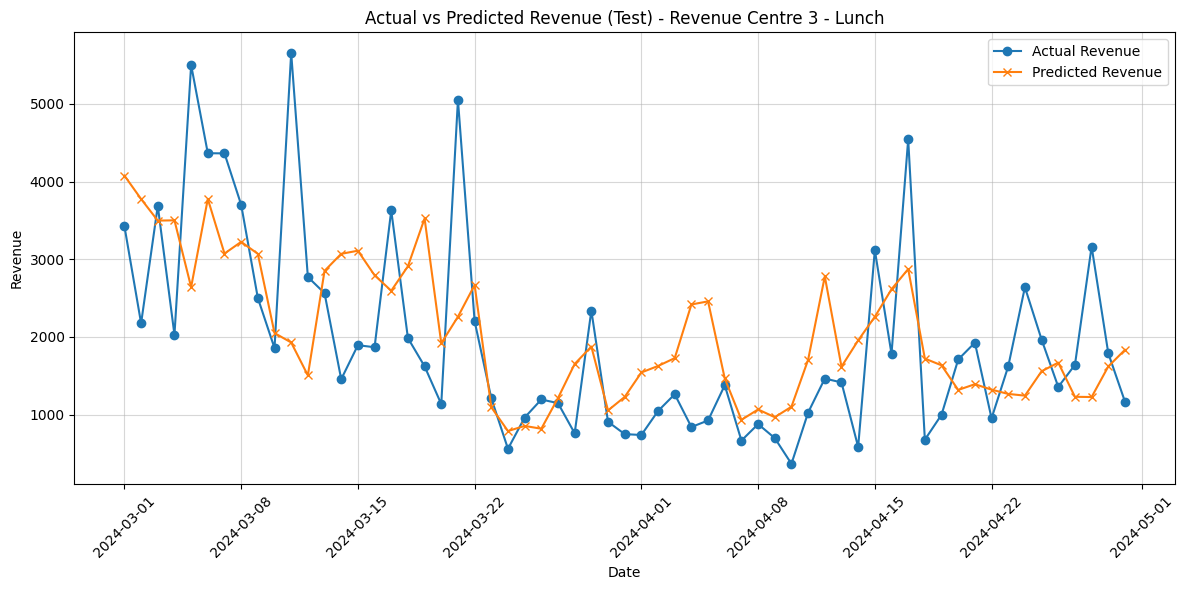

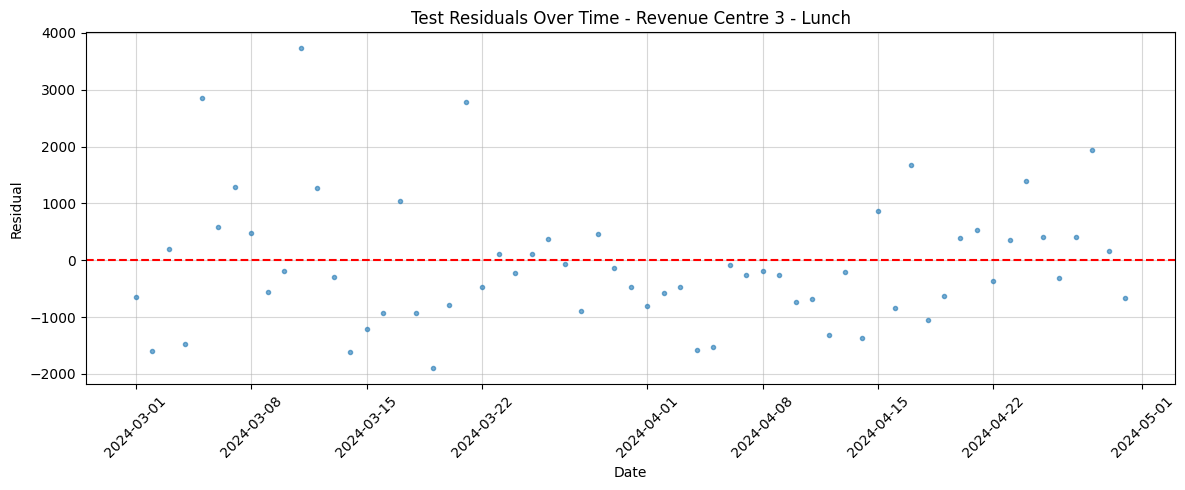


================= Revenue Centre 4 =================

🎲 Random Search for Revenue Centre 4 - BreakFast: 3 sampled combos
✅ Best Params for Revenue Centre 4 - BreakFast: LR=0.01000, Units=64, Alpha=10.00, Avg CV RMSE=0.00
✅ Ensemble weights (from CV): LSTM=0.000, Ridge=1.000

--- FINAL TEST RESULTS (Revenue Centre 4 - BreakFast) ---
TEST RMSE: 0.00, TEST MAE: 0.00, TEST sMAPE: 0.00%, TEST MAPE: 0.00%


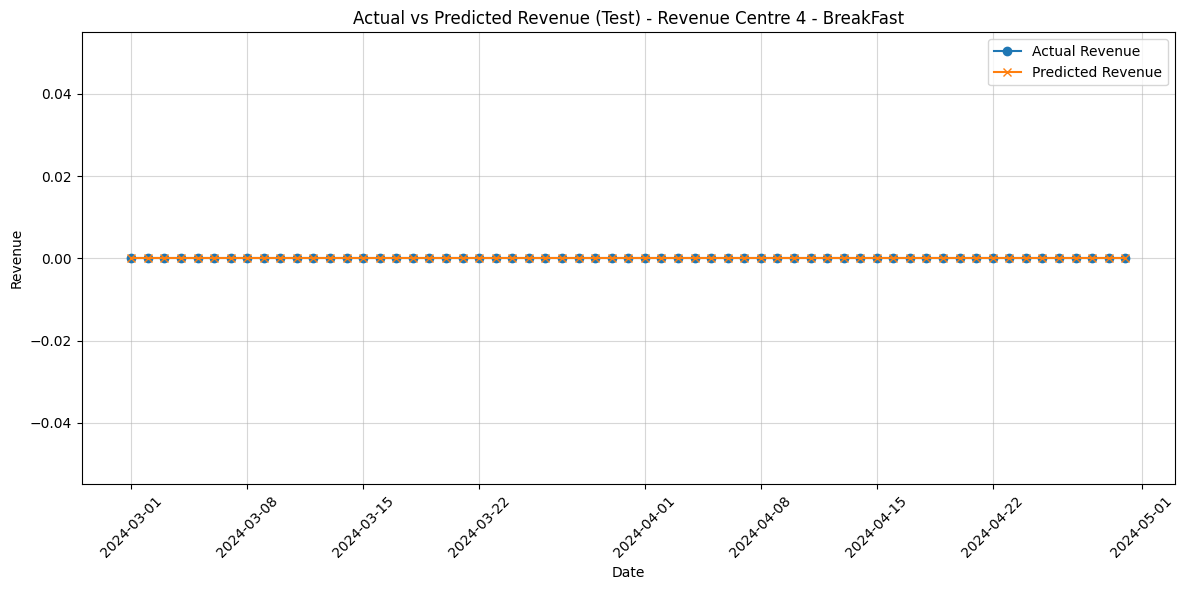

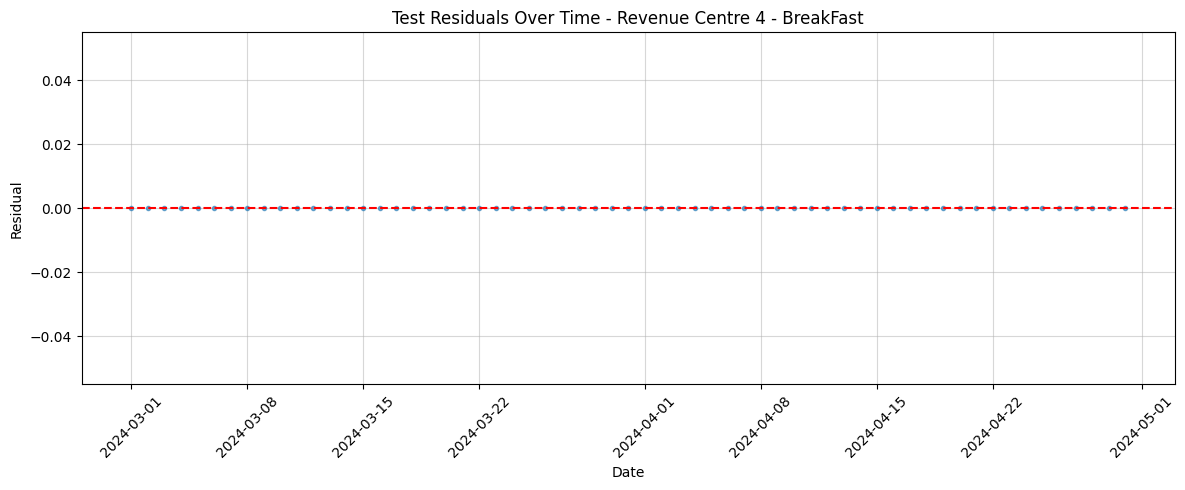


🎲 Random Search for Revenue Centre 4 - Dinner: 12 sampled combos
✅ Best Params for Revenue Centre 4 - Dinner: LR=0.00050, Units=128, Alpha=10.00, Avg CV RMSE=0.00
✅ Ensemble weights (from CV): LSTM=0.224, Ridge=0.776

--- FINAL TEST RESULTS (Revenue Centre 4 - Dinner) ---
TEST RMSE: 0.00, TEST MAE: 0.00, TEST sMAPE: 200.00%, TEST MAPE: 97208.39%


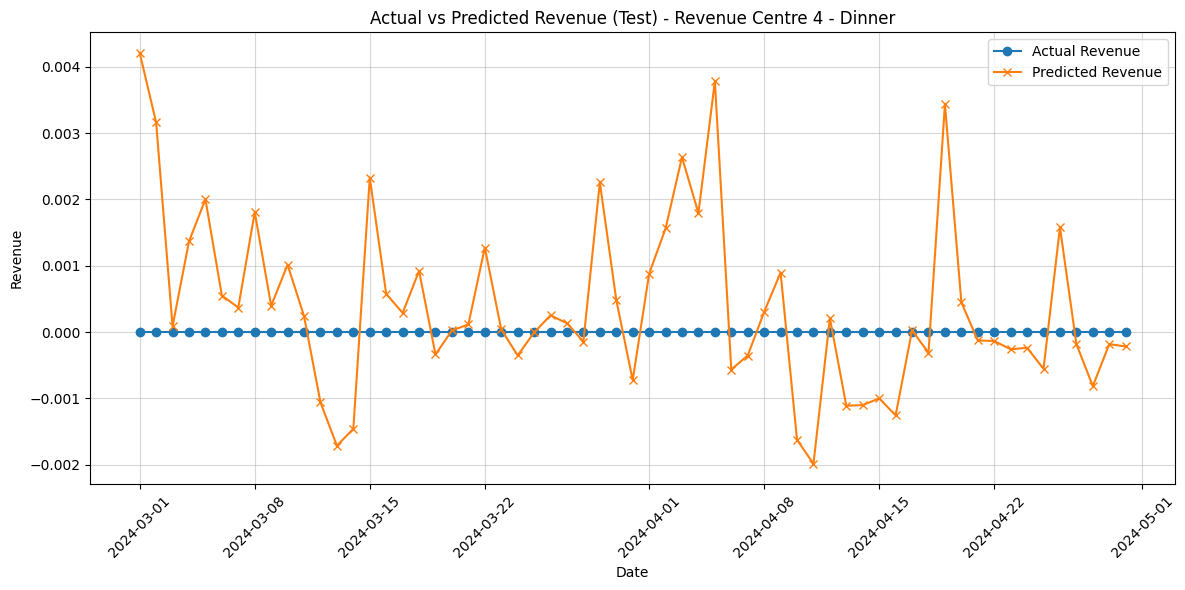

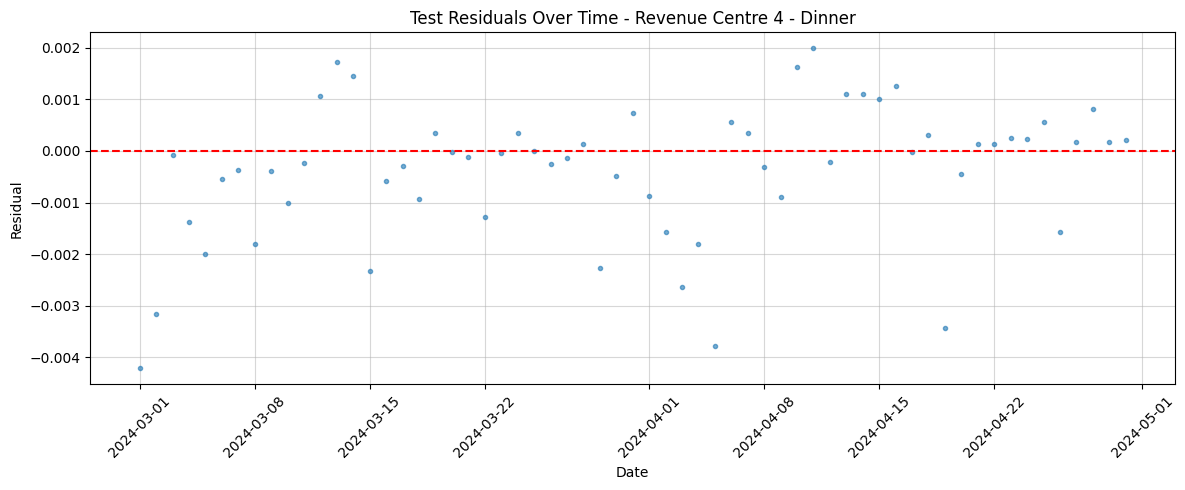


🎲 Random Search for Revenue Centre 4 - Lunch: 12 sampled combos
✅ Best Params for Revenue Centre 4 - Lunch: LR=0.00100, Units=128, Alpha=10.00, Avg CV RMSE=0.00
✅ Ensemble weights (from CV): LSTM=0.000, Ridge=1.000

--- FINAL TEST RESULTS (Revenue Centre 4 - Lunch) ---
TEST RMSE: 0.00, TEST MAE: 0.00, TEST sMAPE: 0.00%, TEST MAPE: 0.00%


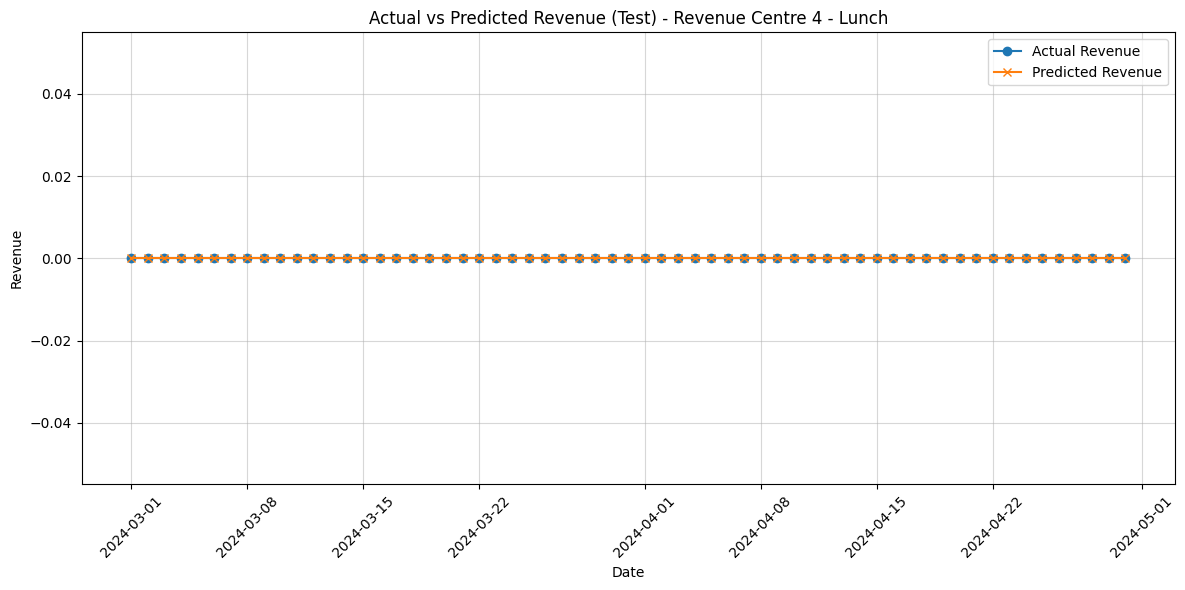

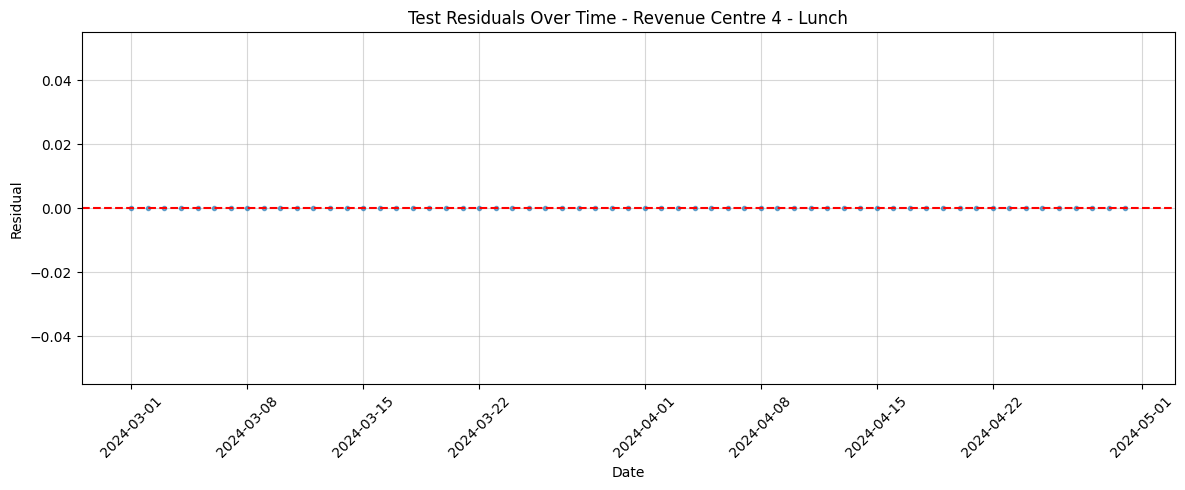

In [50]:

def load_center_from_excel(file_path, center_sheet_name):
    """
    Load one center's sheet from Excel and parse Date column.
    """
    df = pd.read_excel(file_path, sheet_name=center_sheet_name)
    if 'Date' in df.columns:
        df['Date'] = pd.to_datetime(df['Date'])
    else:
        raise ValueError("Expected a 'Date' column in the sheet.")
    return df


if __name__ == '__main__':
    for center_id in range(2, 4):
        try:
            df_center = load_center_from_excel(INPUT_FILE_NAME, center_id)
            display_name = f"Revenue Centre {center_id+1}"
            print(f"\n================= {display_name} =================")
            # Train and evaluate for this center
            train_and_plot_for_center(df_center, display_name)
        except Exception as e:
            print(f"⚠️ Skipping {center_id}: {e}")


================= Revenue Centre 5 =================

🎲 Random Search for Revenue Centre 5 - BreakFast: 3 sampled combos
✅ Best Params for Revenue Centre 5 - BreakFast: LR=0.01000, Units=64, Alpha=10.00, Avg CV RMSE=4795.66
✅ Ensemble weights (from CV): LSTM=0.413, Ridge=0.587

--- FINAL TEST RESULTS (Revenue Centre 5 - BreakFast) ---
TEST RMSE: 3370.24, TEST MAE: 2783.65, TEST sMAPE: 16.79%, TEST MAPE: 18.47%


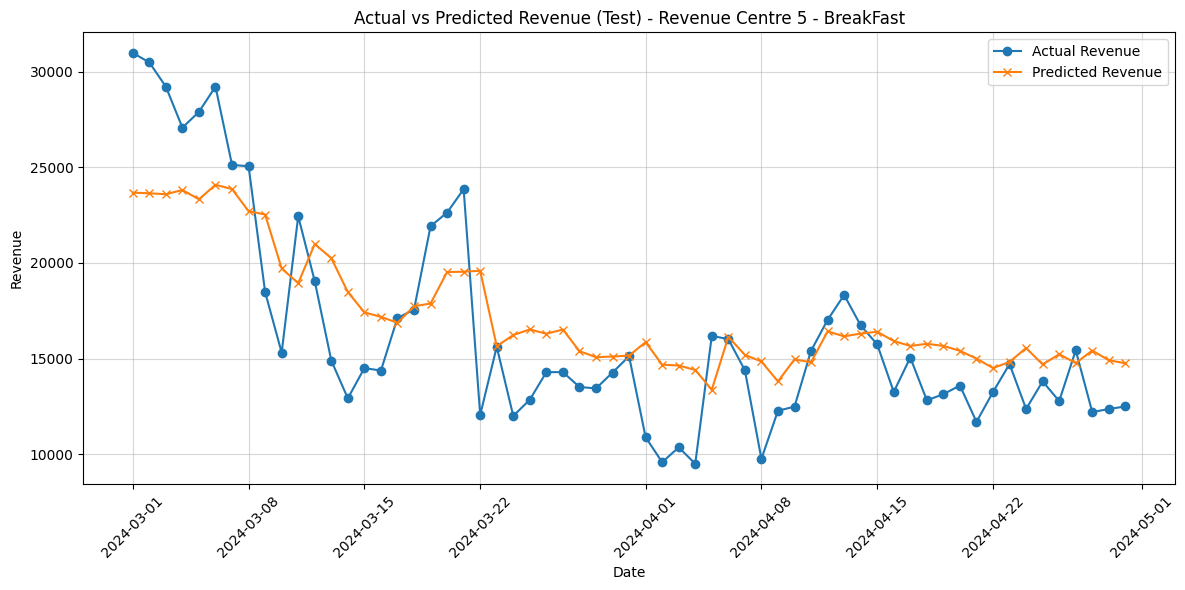

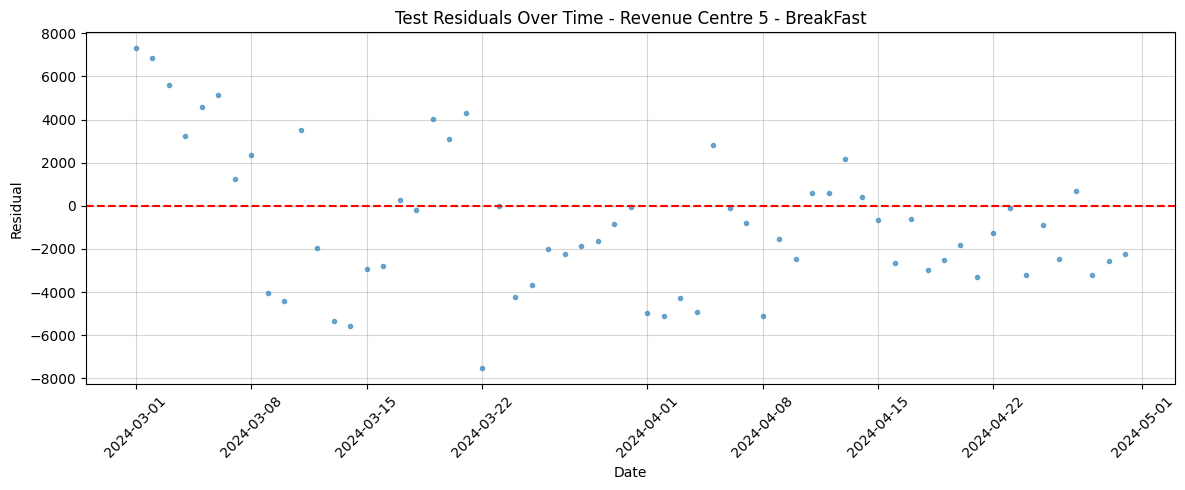


🎲 Random Search for Revenue Centre 5 - Dinner: 12 sampled combos
✅ Best Params for Revenue Centre 5 - Dinner: LR=0.00100, Units=128, Alpha=1.00, Avg CV RMSE=5865.60
✅ Ensemble weights (from CV): LSTM=0.514, Ridge=0.486

--- FINAL TEST RESULTS (Revenue Centre 5 - Dinner) ---
TEST RMSE: 9377.57, TEST MAE: 5804.71, TEST sMAPE: 46.03%, TEST MAPE: 49.11%


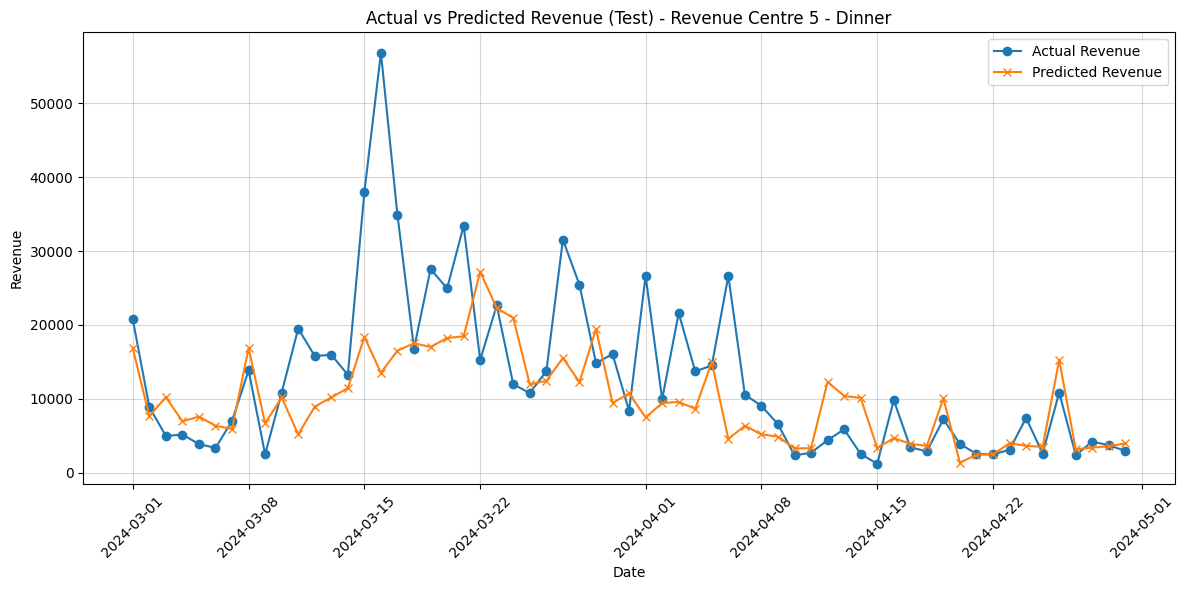

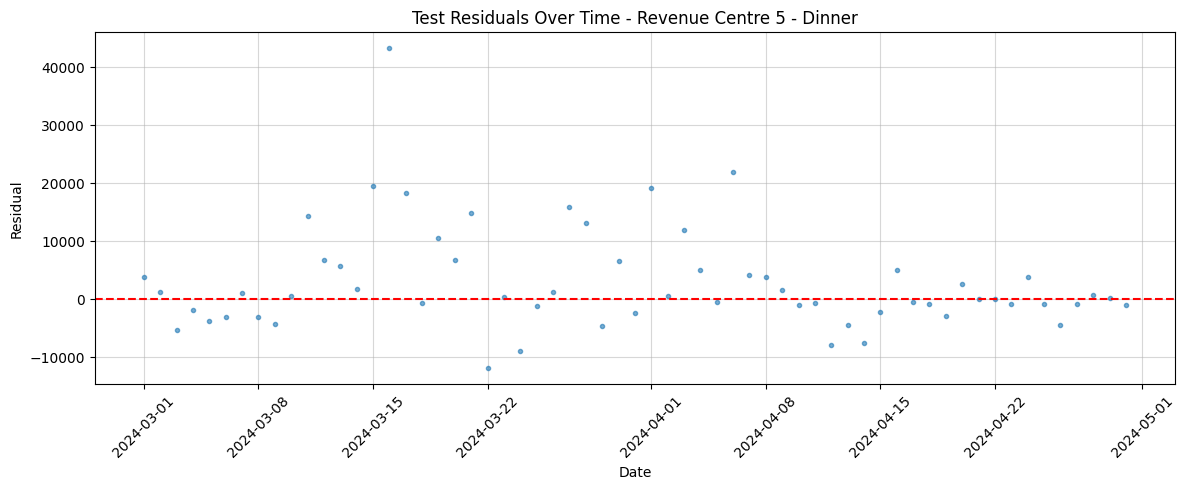


🎲 Random Search for Revenue Centre 5 - Lunch: 12 sampled combos
✅ Best Params for Revenue Centre 5 - Lunch: LR=0.00200, Units=128, Alpha=10.00, Avg CV RMSE=2967.23
✅ Ensemble weights (from CV): LSTM=0.484, Ridge=0.516

--- FINAL TEST RESULTS (Revenue Centre 5 - Lunch) ---
TEST RMSE: 3619.60, TEST MAE: 1809.73, TEST sMAPE: 92.70%, TEST MAPE: 8957736091.56%


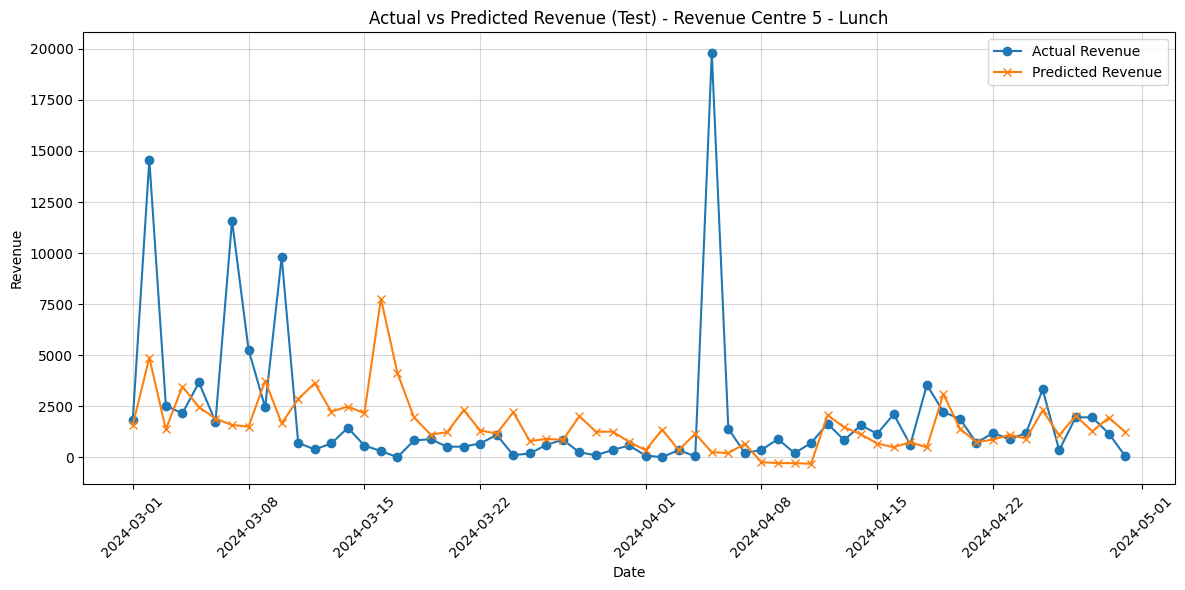

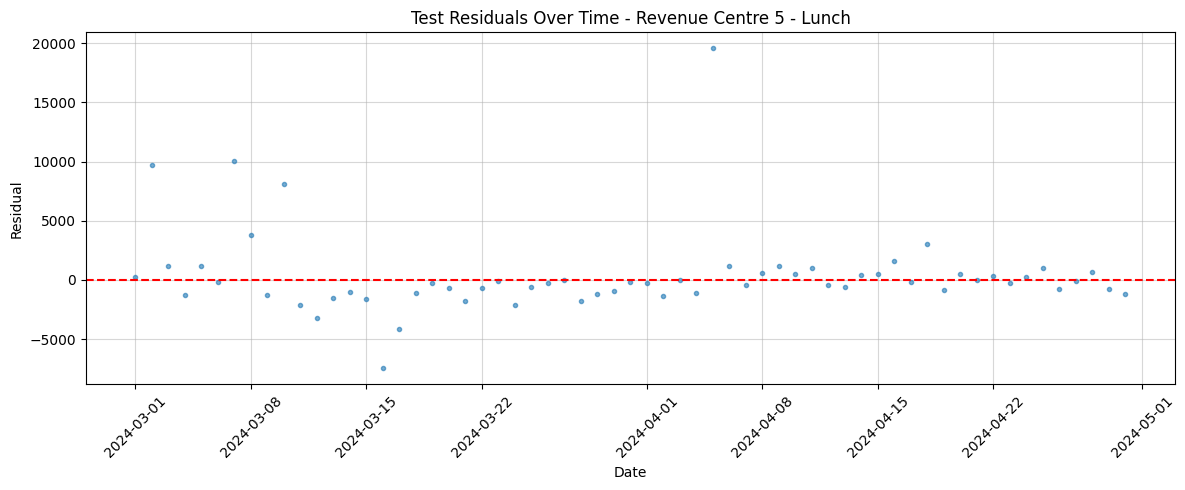

In [51]:

def load_center_from_excel(file_path, center_sheet_name):
    """
    Load one center's sheet from Excel and parse Date column.
    """
    df = pd.read_excel(file_path, sheet_name=center_sheet_name)
    if 'Date' in df.columns:
        df['Date'] = pd.to_datetime(df['Date'])
    else:
        raise ValueError("Expected a 'Date' column in the sheet.")
    return df


if __name__ == '__main__':
    for center_id in range(4, 5):
        try:
            df_center = load_center_from_excel(INPUT_FILE_NAME, center_id)
            display_name = f"Revenue Centre {center_id+1}"
            print(f"\n================= {display_name} =================")
            # Train and evaluate for this center
            train_and_plot_for_center(df_center, display_name)
        except Exception as e:
            print(f"⚠️ Skipping {center_id}: {e}")